In [1]:
import os, re
import time

import pickle 
import numpy as np
from hybrid_estimator.batchCVP import batchCVPP_cost
out_path = "lwe_instances/reduced_lattices/"

# with open( "./agr.pkl", "rb" ) as file:
#     otmp = pickle.load( file )

# o = []
# for oo in otmp:
#     if oo['kyb'][0] in [140,150,160]:
#         o.append( oo )

sec_type = "binomial"
sec_param = 3

with open("./lwe_instances/reduced_lattices/exp_[140, 150, 160, 170]_3329_binomial_3.pkl", "rb") as file:
    out = pickle.load( file )
    
lwe_inst = [ #do we need lats_per_dim and inst_per_lat?
    {"n": 140, "q": 3329, "dist": 'binomial', "dist_param": 3},
    {"n": 150, "q": 3329, "dist": 'binomial', "dist_param": 3},
    {"n": 160, "q": 3329, "dist": 'binomial', "dist_param": 3},
    {"n": 170, "q": 3329, "dist": 'binomial', "dist_param": 3},
]

hparams = { #n_guess_coord's, n_slicer_coord from preprocessing.py
    140: (1,61),
    150: (1,71),
    160: (1,81),
    170: (1,91)
}


outpre = []
q, eta, k = 3329, 3, 1
corresponding_blocksizes = {140:55, 150:55, 160:55, 170: 80, 180: 90}
for n in range(140,181,10):
    betapre = corresponding_blocksizes[n]
    for seed in range(10):
        filename = f"report_pre_{n}_{q}_{eta}_{k}_{seed}_{betapre}.pkl"
        with open( out_path + filename, "rb" ) as file:
            outpre.append( pickle.load( file ) )

print(outpre)

maxbeta =0
for oo in out:
    if oo["beta"] > maxbeta:
        maxbeta = oo["beta"]

print( maxbeta )

[{'kyb': (140, 3329, 3, 1, [0, 0]), 'beta': 55, 'time': 1037.788861399999}, {'kyb': (140, 3329, 3, 1, [1, 0]), 'beta': 55, 'time': 1038.6644370000022}, {'kyb': (140, 3329, 3, 1, [2, 0]), 'beta': 55, 'time': 1039.4054464000005}, {'kyb': (140, 3329, 3, 1, [3, 0]), 'beta': 55, 'time': 1044.273380999999}, {'kyb': (140, 3329, 3, 1, [4, 0]), 'beta': 55, 'time': 1038.0547055000002}, {'kyb': (140, 3329, 3, 1, [5, 0]), 'beta': 55, 'time': 1108.0185189999993}, {'kyb': (140, 3329, 3, 1, [6, 0]), 'beta': 55, 'time': 1114.9309392000023}, {'kyb': (140, 3329, 3, 1, [7, 0]), 'beta': 55, 'time': 1108.6796758000005}, {'kyb': (140, 3329, 3, 1, [8, 0]), 'beta': 55, 'time': 1106.8043052000003}, {'kyb': (140, 3329, 3, 1, [9, 0]), 'beta': 55, 'time': 1105.624163599999}, {'kyb': (150, 3329, 3, 1, [0, 0]), 'beta': 55, 'time': 1660.0625950461254}, {'kyb': (150, 3329, 3, 1, [1, 0]), 'beta': 55, 'time': 1667.843117679935}, {'kyb': (150, 3329, 3, 1, [2, 0]), 'beta': 55, 'time': 1656.4233464435674}, {'kyb': (150, 3

{140: 61.4700000000000, 150: 72.1400000000000, 160: 82.0800000000000, 170: 91.7500000000000, 180: 100.530000000000}
{140: 3.4509563891767745, 150: 3.666115110031326, 160: 2.8937173324289986, 170: 2.878801834096956, 180: 2.666289556668593}


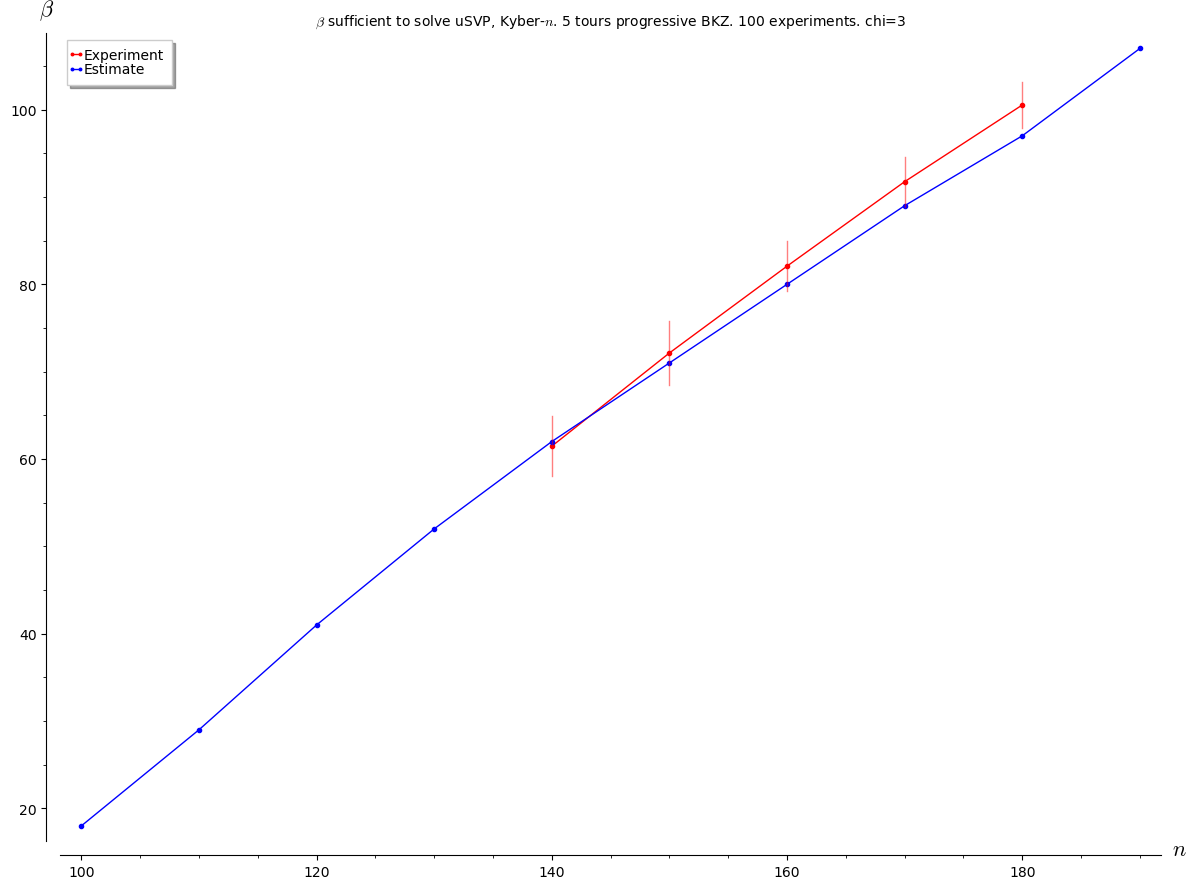

In [2]:
start, step, times = 140, 10, 5
l = {}
ddl = {} #{ start+step*i: 0 for i in range(times) }
for oo in out:
    if not oo["kyb"][0] in l.keys():
        l[oo["kyb"][0]] = [ oo["beta"], 1 ]
        ddl[oo["kyb"][0]] = [ oo["beta"] ]
    else:
        l[oo["kyb"][0]][0] += oo["beta"]
        l[oo["kyb"][0]][1] += 1
        ddl[oo["kyb"][0]].append( oo["beta"] )

for key in l.keys():
    l[key] = l[key][0]/l[key][1].n()
    ddl[key] = np.std(ddl[key])

print( l )
print( ddl )
chi = out[0]['kyb'][2]

predict3 = [(100,18),(110,29),(120,41),(130,52),(140,62),(150,71),(160,80),(170,89),(180,97),(190,107)]
predict2 = [(100,11),(110,21),(120,32),(130,44),(140,54),(150,63),(160,72),(170,80),(180,89),(190,97)]
P = list_plot(l, plotjoined=True, marker='.',color="red", legend_label="Experiment") + list_plot(predict3, plotjoined=True, marker='.', legend_label="Estimate")

for ii in range(times):
    i = start+step*ii
    P += plot( line( [(i,l[i]+ddl[i]),(i,l[i]-ddl[i])], color="red", alpha=0.5 ) )

P.show( axes_labels=['$n$', '$\\beta$'], title=f'$\\beta$ sufficient to solve uSVP, Kyber-$n$. 5 tours progressive BKZ. 100 experiments. chi={chi}', figsize=12 )

exp_[140, 150, 160, 170]_3329_binomial_3.pkl 180
report_prehyb_140_3329_binomial_3.0000_0_1_62_63_61.pkl 180
report_prehyb_140_3329_binomial_3.0000_0_1_62_63_61.pkl
61 61
True True True True True True
yes: report_prehyb_140_3329_binomial_3.0000_0_1_62_63_61.pkl
report_prehyb_140_3329_binomial_3.0000_1_1_62_63_61.pkl 140
report_prehyb_140_3329_binomial_3.0000_1_1_62_63_61.pkl
61 61
True True True True True True
yes: report_prehyb_140_3329_binomial_3.0000_1_1_62_63_61.pkl
report_prehyb_140_3329_binomial_3.0000_2_1_62_63_61.pkl 140
report_prehyb_140_3329_binomial_3.0000_2_1_62_63_61.pkl
61 61
True True True True True True
yes: report_prehyb_140_3329_binomial_3.0000_2_1_62_63_61.pkl
report_prehyb_140_3329_binomial_3.0000_3_1_62_63_61.pkl 140
report_prehyb_140_3329_binomial_3.0000_3_1_62_63_61.pkl
61 61
True True True True True True
yes: report_prehyb_140_3329_binomial_3.0000_3_1_62_63_61.pkl
report_prehyb_140_3329_binomial_3.0000_4_1_62_63_61.pkl 140
report_prehyb_140_3329_binomial_3.0000_

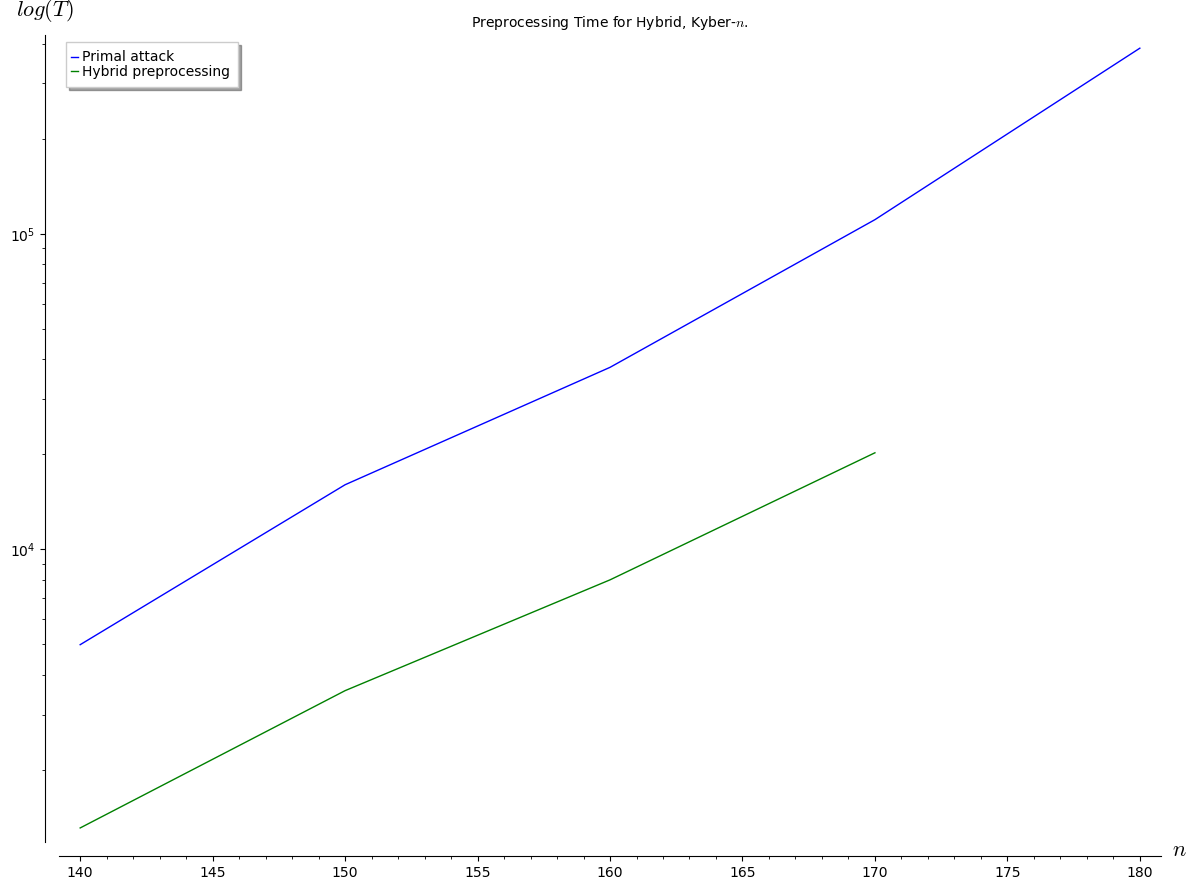

In [3]:
from sample import Distribution, ternaryDist, centeredBinomial

from hybrid_estimator.batchCVP import batchCVPP_cost


if sec_type=="binomial":
    distrib = centeredBinomial(sec_param)
elif sec_type=="ternary":
     print(f"sec_param: {sec_param}")
     distrib = ternaryDist(sec_param)

# extracting the primal preprocessing timing
r = {}
for oo in outpre:
    n, seed = oo['kyb'][0], oo['kyb'][4][0]
    if not n in r.keys(): 
        r[n] = [ oo["time"], 1 ]
    else:
        r[n][0] += oo["time"]
        r[n][1] += 1


#averaging the timing
for key in r.keys():
    r[key] = r[key][0]/r[key][1].n()

# extracting the primal attack timing
l = {}
for oo in out:
    if not oo["kyb"][0] in l.keys():
        l[oo["kyb"][0]] = [ oo["time"], 1 ]
    else:
        l[oo["kyb"][0]][0] += oo["time"]
        l[oo["kyb"][0]][1] += 1

# averaging it
for key in l.keys():
    l[key] = l[key][0]/l[key][1].n() + r[key]
    ddl[key] = np.std(ddl[key])

primal_timings = deepcopy(l)
# - - - 
P = list_plot_semilogy(l, plotjoined=True, legend_label="Primal attack")

data = []
path = "./lwe_instances/reduced_lattices/"
# regex = re.compile(r'^report_prehyb_(\d+)_')
pattern = re.compile(r'''
    ^report_prehyb_             
    (?P<n>\d+)_                 
    (?P<q>\d+)_                 
    (?P<dist>[^_]+)_            
    (?P<dist_param>[+-]?\d+\.\d{4})_  
    (?P<seed>\d+)_              
    (?P<kappa>\d+)_             
    (?P<sieve_dim_min>\d+)_     
    (?P<sieve_dim_max>\d+)_     
    (?P<beta_bkz>\d+)           
    \.pkl$
''', re.VERBOSE)
regex = re.compile(pattern)

for path, directories, files in os.walk(path):
    for candidate in files:
        match = regex.match(candidate)
        print(candidate, n)
        if match and sec_type in candidate and f"{sec_param:0.4f}" in candidate:
            gd = match.groupdict()
            n             = int(gd['n'])
            q             = int(gd['q'])
            dist          = gd['dist']
            dist_param    = float(gd['dist_param'])
            seed          = int(gd['seed'])
            kappa         = int(gd['kappa'])
            sieve_dim_min = int(gd['sieve_dim_min'])
            sieve_dim_max = int(gd['sieve_dim_max'])
            beta_bkz      = int(gd['beta_bkz'])
            # print(f"n: {n} sec: {sec_type} {kappa}")
            print(f"{candidate}")
            try:
                # try:
                #     print(ncur)
                # except KeyError:
                #     continue
                try:
                    # print(
                    #     n in [tmp["n"] for tmp in lwe_inst] ,
                    #     kappa==hparams[n][0] ,
                    #     beta_bkz == hparams[n][1],
                    #     sec_type in candidate ,
                    #     f"{sec_param:0.4f}" in candidate ,
                    #     f"_{hparams[n][0]}_" in candidate
                    # )
                    if ( #ncur in [tmp["n"] for tmp in lwe_inst] and
                        n in [tmp["n"] for tmp in lwe_inst] and
                        kappa == hparams[n][0] and
                        beta_bkz == hparams[n][1] and
                        sec_type in candidate and
                        f"{sec_param:0.4f}" in candidate and
                        f"_{hparams[n][0]}_" in candidate
                    ):
                        with open( path+candidate, "rb" ) as file:
                            data.append( pickle.load(file) )
                except KeyError as err:
                    print( err )
                    pass
            except ValueError as expt:
                print(expt)
                pass

processed_data = {}
for D in data: #loading from the text output
    n, q, dist, sec_param, seed = D["params"]
    if dist != sec_type:
        print(f"wrong dist: {dist}")
        continue
    sieve_dim_max = D["sieve_dim_max"]
    sieve_dim_min = D["sieve_dim_min"]
    kappa = D["kappa"]
    if kappa != hparams[n][0]: #or sieve_dim_min != hparams[n][1]:
        continue
    
    bkz_runtime = D["bkz_runtime"]
    bdgl_runtime = D["bdgl_runtime"]

    nsampl = ceil( 2 ** ( distrib.entropy * kappa ) )

    for i in range(len(bdgl_runtime)):
        sievedim = sieve_dim_max-i
        latdim = n - kappa
        if not (n,kappa,sievedim,latdim) in processed_data.keys():
            processed_data[(n,kappa,sievedim,latdim)] = {"bkz_runtime": [], "bdgl_runtime": [], "succrate": 0.}
        processed_data[(n,kappa,sievedim,latdim)]["bkz_runtime"].append( bkz_runtime )
        processed_data[(n,kappa,sievedim,latdim)]["bdgl_runtime"].append( bdgl_runtime )

aggrigated_data = {}
for (n,k,sievedim,latdim) in processed_data.keys():
    D = processed_data[(n,k,sievedim,latdim)]
    bkz_runtime = np.mean( D["bkz_runtime"] )
    bdgl_runtime = np.mean( D["bdgl_runtime"], axis=int(0) )
    
    aggrigated_data[ (n,k,sievedim) ] =  bkz_runtime + np.zeros(len(bdgl_runtime))



l0, l1 = {}, {}

for (n,k,sievedim) in aggrigated_data.keys():
    l0[n] = aggrigated_data[(n,k,sievedim)][-1]
    l1[n] = aggrigated_data[(n,k,sievedim)][0]

print(l)
print(l1)

preprocess_hyb_time = deepcopy(l0)

P += list_plot_semilogy(l0, plotjoined=True, base=10, axes_labels=["$n$", "$log(T)$"], color="green", legend_label="Hybrid preprocessing")
P.show( title=f'Preprocessing Time for Hybrid, Kyber-$n$.', figsize=12 )

aaaa: exp_[140, 150, 160, 170]_3329_binomial_3.pkl | None
aaaa: report_prehyb_140_3329_binomial_3.0000_0_1_62_63_61.pkl | None
aaaa: report_prehyb_140_3329_binomial_3.0000_1_1_62_63_61.pkl | None
aaaa: report_prehyb_140_3329_binomial_3.0000_2_1_62_63_61.pkl | None
aaaa: report_prehyb_140_3329_binomial_3.0000_3_1_62_63_61.pkl | None
aaaa: report_prehyb_140_3329_binomial_3.0000_4_1_62_63_61.pkl | None
aaaa: report_prehyb_140_3329_binomial_3.0000_5_1_62_63_61.pkl | None
aaaa: report_prehyb_140_3329_binomial_3.0000_6_1_62_63_61.pkl | None
aaaa: report_prehyb_140_3329_binomial_3.0000_7_1_62_63_61.pkl | None
aaaa: report_prehyb_140_3329_binomial_3.0000_8_1_62_63_61.pkl | None
aaaa: report_prehyb_140_3329_binomial_3.0000_9_1_62_63_61.pkl | None
aaaa: report_prehyb_150_3329_binomial_3.0000_0_1_72_73_71.pkl | None
aaaa: report_prehyb_150_3329_binomial_3.0000_1_1_72_73_71.pkl | None
aaaa: report_prehyb_150_3329_binomial_3.0000_2_1_72_73_71.pkl | None
aaaa: report_prehyb_150_3329_binomial_3.0000_

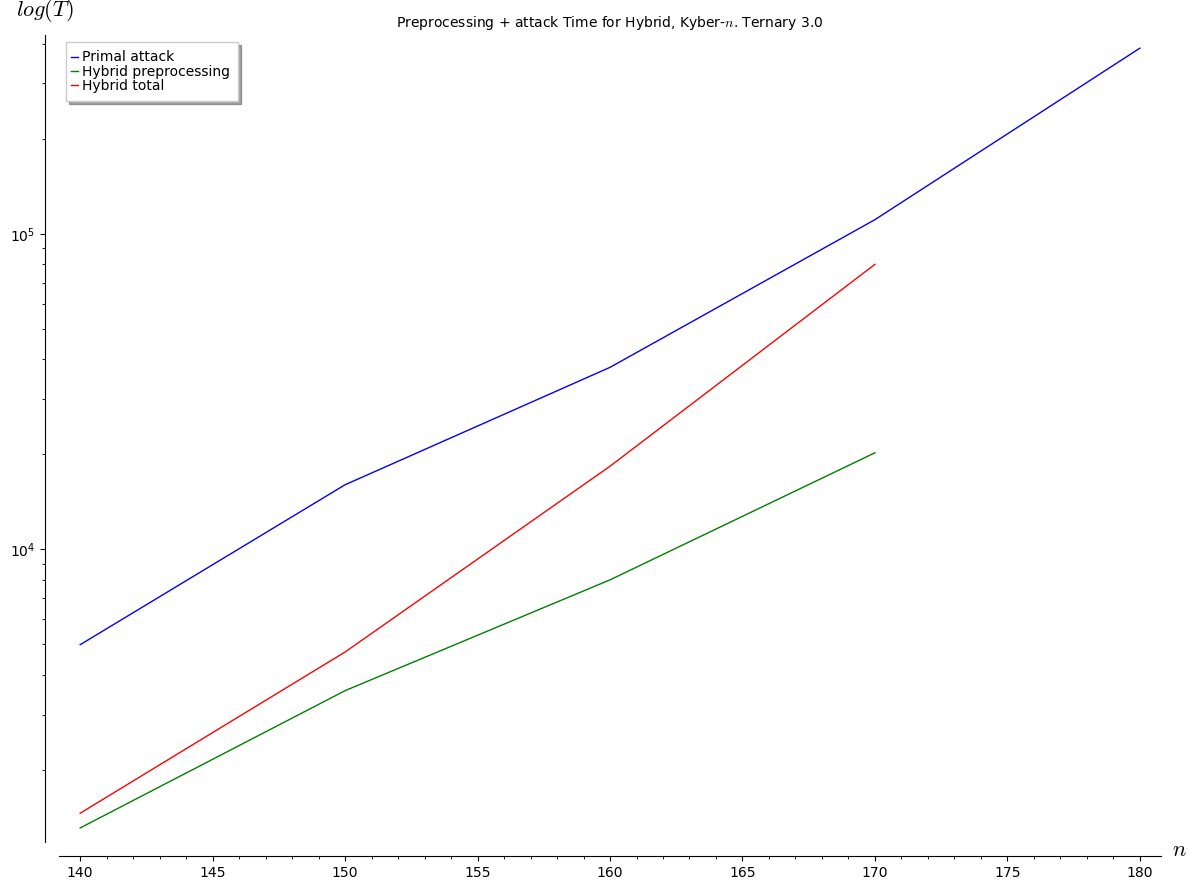

In [4]:
L = {}
available_ns = []
"""
The tha files now have a new naming convention.
"""

data = []
path = "./lwe_instances/reduced_lattices/"
# regex = re.compile(r'^report_prehyb_(\d+)_')
pattern = re.compile(r'''
    ^tph_                          # need that underscore!
    (?P<n>\d+)_                    # 170
    (?P<dist>[^_]+)_               # binomial
    (?P<dist_param>[+-]?\d+\.\d{4})_  # 3.0000
    (?P<kappa>\d+)_                # 1
    (?P<beta_bkz>\d+)_             # 91
    (?P<sieve_dim_max>\d+)         # 93
    \.pkl$                         # literal extension
''', re.VERBOSE)
regex = re.compile(pattern)

lol=0
max_n = 0
for path, directories, files in os.walk(path):
    lol+=1
    for candidate in files:
        match = regex.match(candidate)
        print(f"aaaa: {candidate} | {match}")
        if match and sec_type in candidate and f"{sec_param:0.4f}" in candidate:
            gd = match.groupdict()
            n             = int(gd['n'])
            dist          = gd['dist']
            dist_param    = float(gd['dist_param'])
            kappa         = int(gd['kappa'])
            sieve_dim_max = int(gd['sieve_dim_max'])
            beta_bkz      = int(gd['beta_bkz'])
            
            available_ns.append(n)
            with open(path+candidate,"rb") as file:
                L.update( pickle.load(file) )
            

wtimes = {}
succs = {}
for n in available_ns:
    wtimes[n] = []
    if not n in succs:
        succs[n] = [0,0]
    
NRAND_FACTOR = 10.
for key in L:
    n, _, n_slicer_coord, n_guess_coord, _ = key
    print(n,n_guess_coord,n_slicer_coord)
    print( n_guess_coord == hparams[n][0] )
    if n_guess_coord == hparams[n][0]:
        print( n,n_guess_coord, hparams[n][0] )
        nrand_, _ = batchCVPP_cost(n_slicer_coord,100,L[key]["g6k_len"] **(1./n_slicer_coord),1)
        nrand = ceil(NRAND_FACTOR*(1./nrand_)**n_slicer_coord)
        utar_per_batch = ceil( L[key]["g6k_len"] / nrand ) #how many unique targets in batch
    
        curtime = abs( L[key]["wrong_guess_time_alg2"] ) + abs( L[key]["wrong_guess_time_alg3"] )
        overhead_tsieve = L[key]["overhead_tsieve"]
        batnum = L[key]["key_num"]/utar_per_batch
        curtime *= batnum  #time * how many batches needed
        wtimes[n].append( curtime + overhead_tsieve )
        succs[n][0]+=1
        succs[n][1]+=L[key]['succ']

for n in available_ns:
    wtimes[n] = np.mean(wtimes[n])
    try:
        print(n)
        cur_succ_rate = float(succs[n][1] / succs[n][0])
    except TypeError:
        cur_succ_rate = succs[n]
    succs[n] = cur_succ_rate if cur_succ_rate>0 else 1/100.

ltot_hyb_att = {}
for key in wtimes.keys():
    walltime = wtimes[key]
    ltot_hyb_att[key] = l1[key] + ( 2*walltime ) / succs[key]  #success rate is 1/2 * slicer's proba

P += list_plot_semilogy(ltot_hyb_att, plotjoined=True, base=10, axes_labels=["$n$", "$log(T)$"], color="red", legend_label="Hybrid total")
plotfilename = f"time_{dist}_{dist_param:0.4f}_{available_ns}.png"
P.show( title=f'Preprocessing + attack Time for Hybrid, Kyber-$n$. Ternary {dist_param}', figsize=12 )

In [12]:
plotfilename = f"time_{dist}_{dist_param:0.4f}_{available_ns}.png"
P.save_image( plotfilename,title=f'Preprocessing + attack Time for Hybrid, Kyber-$n$. Ternary', figsize=12 )

primal_timings, preprocess_hyb_time, ltot_hyb_att

file_primal = open("csvs/primal_binom.csv","w")
file_prehyb = open("csvs/prehyb_binom.csv","w")
file_hybtot = open("csvs/tothyb_binom.csv","w")
file_primal.write("n, T\n")
file_prehyb.write("n, T\n")
file_hybtot.write("n, T\n")
for n in range(140, 171, 10):
    file_primal.write(f"{n}, {primal_timings[n]}\n")
    file_prehyb.write(f"{n}, {preprocess_hyb_time[n]}\n")
    file_hybtot.write(f"{n}, {ltot_hyb_att[n]}\n")
    

file_primal.close()
file_prehyb.close()
file_hybtot.close()

In [44]:
t = np.array( [ [1,2,3], [4,5,6] ] )
np.mean( t,axis=1 )

array([2., 5.])

In [14]:
L

{(140, 0, 67, 1, 1): {'walltime': 1.5435598148033023,
  'dist_bnd': 1.1673538113104187,
  'succ': False,
  'fail_reason': 'parasites',
  'key_num': 6,
  'g6k_len': 49046,
  'g6k_dim': 67,
  'wrong_guess_time_alg3': 0.7811739379540086,
  'correct_guess_time_alg3': 1.921587835997343,
  'wrong_guess_time_alg2': 0.7623858768492937,
  'correct_guess_time_alg2': 1.90318036172539,
  'walltime_observed': 2.723037153482437,
  'overhead_tsieve': 22.25676310248673},
 (140, 0, 67, 1, 2): {'walltime': 54.591041054576635,
  'dist_bnd': 0.8166007851757219,
  'succ': True,
  'fail_reason': None,
  'key_num': 6,
  'g6k_len': 49046,
  'g6k_dim': 67,
  'wrong_guess_time_alg3': 27.304892661981285,
  'correct_guess_time_alg3': 25.093920030631125,
  'wrong_guess_time_alg2': 27.28614839259535,
  'correct_guess_time_alg2': 25.073344287462533,
  'walltime_observed': 52.40600877813995,
  'overhead_tsieve': 22.25676310248673},
 (140, 0, 67, 1, 3): {'walltime': 53.22148988395929,
  'dist_bnd': 1.02052892001105,
 

In [51]:
hparams

[(140, 3, 56), (150, 3, 66)]

In [22]:
45*60

2700